In [ ]:
# Run from the repo root so data/, models/, results/ and scripts/ resolve
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
if 'scripts' not in sys.path:
    sys.path.insert(0, 'scripts')

# RISE Experiment — Visual Inspection & Model Inference

This notebook lets you:
1. **Inspect RISE sequences** — see how each image degrades across 20 steps
2. **Run the gray model** on a sequence and watch per-step confidence
3. **Run the full experiment** over the validation set and plot detection thresholds

Random Image Structure Evolution (Sadr & Sinha, 2004) as used in Kawai & He (2016).
Each image goes from 95% phase-scrambled (step 1) → original (step 20).
Detection threshold = first step at which the model predicts the correct class.

In [1]:
import sys
sys.path.insert(0, 'scripts')   # make rise.py importable

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from fastai.vision.all import *
from torchvision.models import resnet18

from rise import generate_rise_sequence, run_model_on_sequence, ALPHAS, N_STEPS

DATA_PATH  = Path('data/sdh_500_clean')
MODEL_GRAY = Path('models/sdhnet-4class-gray-best.pth')
CLASSES    = ['bird', 'cat', 'fish', 'snake']
VALID_DIR  = DATA_PATH / 'valid'

## 1 — Visual inspection: RISE contact sheets

Pick one image per class and display all 20 steps side by side.
Step 1 is the most scrambled; step 20 is the original.

In [2]:
def show_rise_contact_sheet(img_path, seed=42, title=None):
    frames = generate_rise_sequence(img_path, seed=seed)
    fig, axes = plt.subplots(1, N_STEPS, figsize=(N_STEPS * 1.2, 1.8))
    for i, (ax, frame) in enumerate(zip(axes, frames)):
        ax.imshow(frame, cmap='gray', vmin=0, vmax=255)
        ax.set_title(str(i + 1), fontsize=7)
        ax.axis('off')
    fig.suptitle(title or Path(img_path).name, fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()

for cls in CLASSES:
    imgs = sorted((VALID_DIR / cls).glob('*.jpg'))
    show_rise_contact_sheet(imgs[0], title=f'{cls}  —  {imgs[0].name}')

<Figure size 2400x180 with 20 Axes>

<Figure size 2400x180 with 20 Axes>

<Figure size 2400x180 with 20 Axes>

<Figure size 2400x180 with 20 Axes>

## 2 — Load the grayscale model

In [3]:
dblock_gray = DataBlock(
    blocks      = (ImageBlock(cls=PILImageBW), CategoryBlock),
    get_items   = get_image_files,
    get_y       = parent_label,
    splitter    = GrandparentSplitter(train_name='train', valid_name='valid'),
    item_tfms   = RandomResizedCrop(224, min_scale=0.75),
    batch_tfms  = [Flip(), Brightness(max_lighting=0.2),
                   Normalize.from_stats([0.449], [0.226])]
)
dls_gray = dblock_gray.dataloaders(DATA_PATH, batch_size=32)
learn_gray = vision_learner(dls_gray, resnet18, metrics=[accuracy], pretrained=False, n_in=1)
learn_gray.load(MODEL_GRAY.stem)
print('Loaded:', MODEL_GRAY)
print('Classes:', dls_gray.vocab)

Loaded: models/sdhnet-4class-gray-best.pth
Classes: ['bird', 'cat', 'fish', 'snake']


/Users/ossie/Documents/Claude/Projects/SDH/sdhnet/.venv/lib/python3.11/site-packages/fastai/learner.py:59: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


## 3 — Model confidence across one RISE sequence

Pick one image and plot the model's class probabilities at every step.
The vertical dashed line marks the detection threshold (first correct prediction).

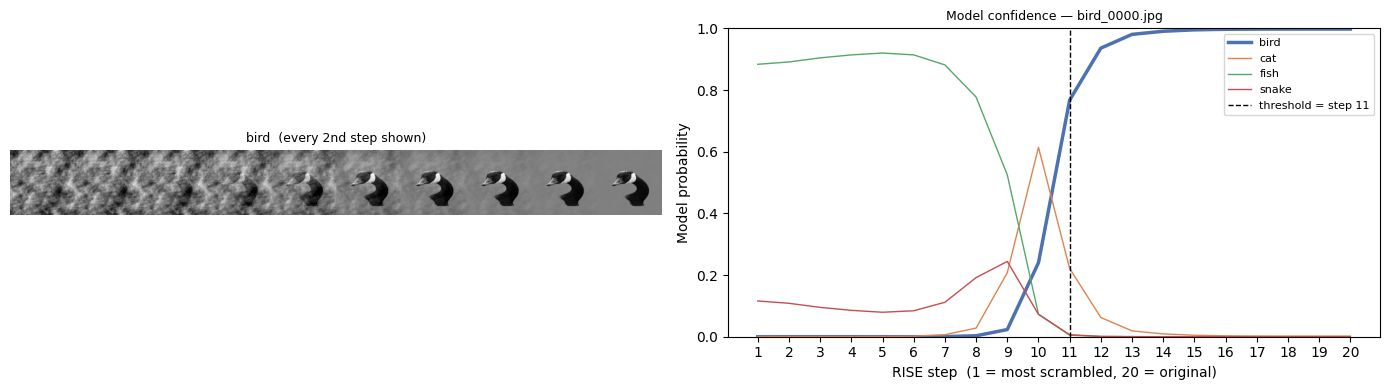

True class: bird  |  Threshold: step 11  |  Final prediction: bird


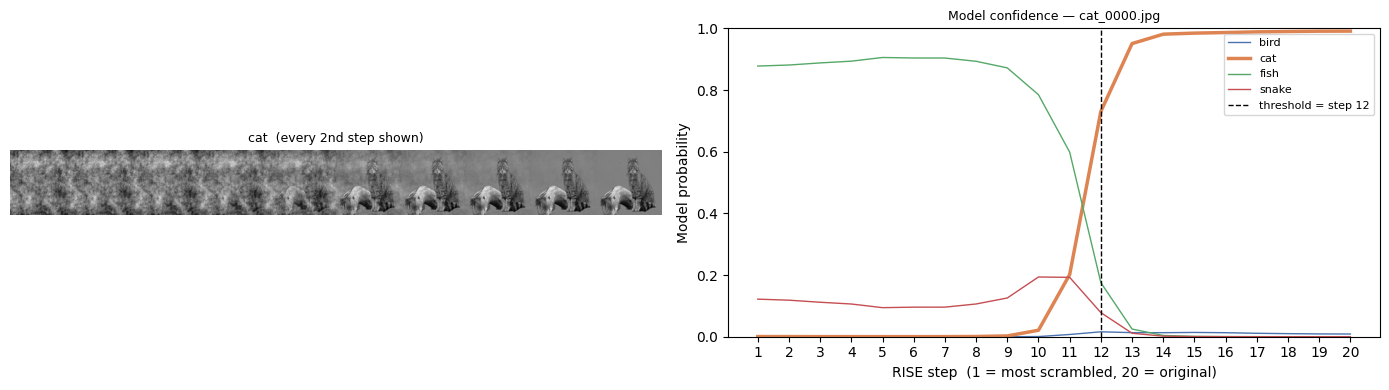

True class: cat  |  Threshold: step 12  |  Final prediction: cat


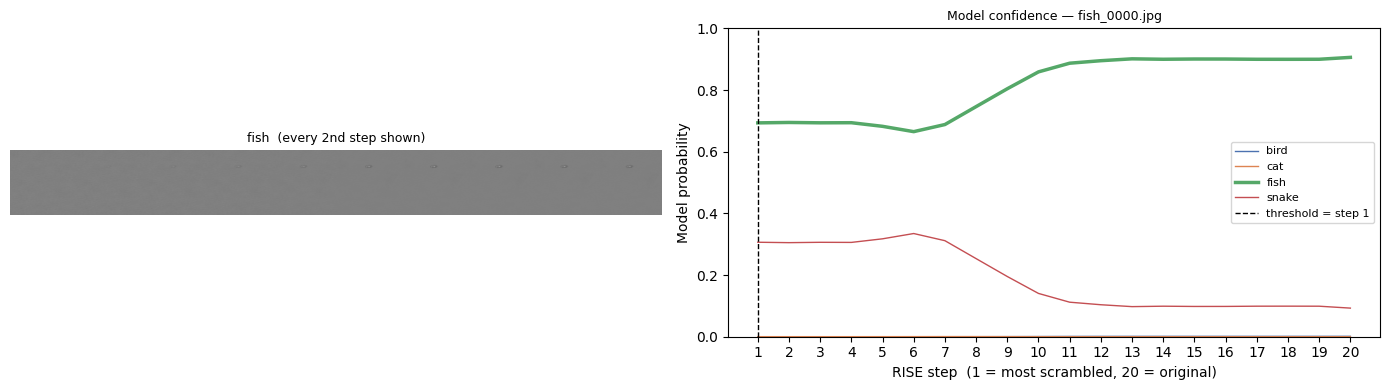

True class: fish  |  Threshold: step 1  |  Final prediction: fish


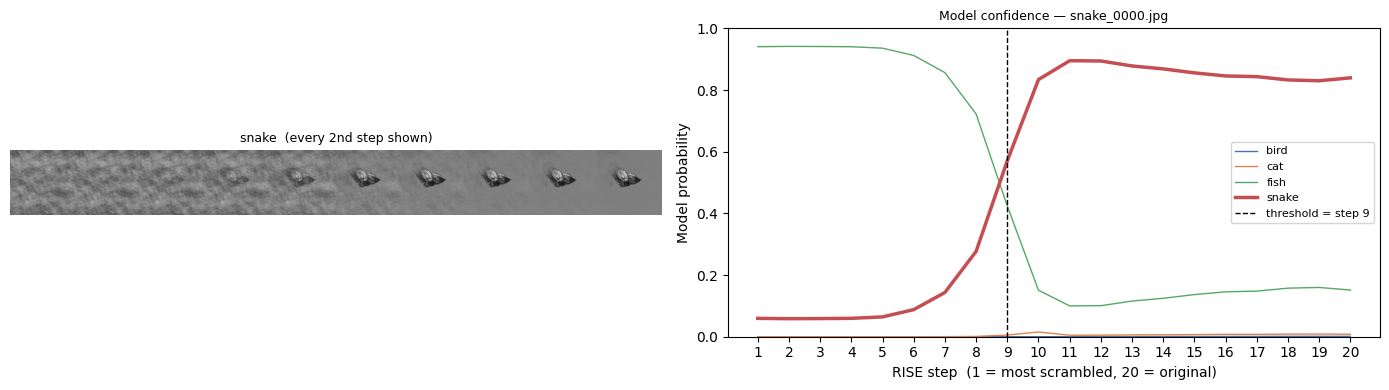

True class: snake  |  Threshold: step 9  |  Final prediction: snake


In [4]:
def plot_rise_inference(img_path, learn, true_class, seed=42):
    frames = generate_rise_sequence(img_path, seed=seed)
    result = run_model_on_sequence(learn, frames, true_class=true_class)

    probs     = result['probs']   # (20, 4)
    threshold = result['threshold']
    vocab     = learn.dls.vocab

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: contact sheet (every other step to save space)
    ax = axes[0]
    ax.axis('off')
    strip = [frames[i] for i in range(0, N_STEPS, 2)]
    strip_img = np.concatenate([np.array(f) for f in strip], axis=1)
    ax.imshow(strip_img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{true_class}  (every 2nd step shown)', fontsize=9)

    # Right: probability curves
    ax = axes[1]
    steps = np.arange(1, N_STEPS + 1)
    colors = {'bird': '#4C72B0', 'cat': '#DD8452', 'fish': '#55A868', 'snake': '#C44E52'}
    for i, cls in enumerate(vocab):
        lw = 2.5 if cls == true_class else 1.0
        ax.plot(steps, probs[:, i], label=cls, color=colors.get(cls, None), linewidth=lw)
    if threshold is not None:
        ax.axvline(threshold, color='black', linestyle='--', linewidth=1,
                   label=f'threshold = step {threshold}')
    ax.set_xlabel('RISE step  (1 = most scrambled, 20 = original)')
    ax.set_ylabel('Model probability')
    ax.set_ylim(0, 1)
    ax.set_xticks(steps)
    ax.legend(fontsize=8)
    ax.set_title(f'Model confidence — {Path(img_path).name}', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'True class: {true_class}  |  Threshold: step {threshold}  |  '
          f'Final prediction: {result["preds"][-1]}')

# Try one image per class
for cls in CLASSES:
    imgs = sorted((VALID_DIR / cls).glob('*.jpg'))
    plot_rise_inference(imgs[0], learn_gray, true_class=cls)

## 4 — Random-weights baseline (untrained model)

Same architecture, never trained. Should output ~25% per class regardless of step,
giving a flat detection threshold around step 10–11 with no class differences.

Random model ready (no weights loaded)


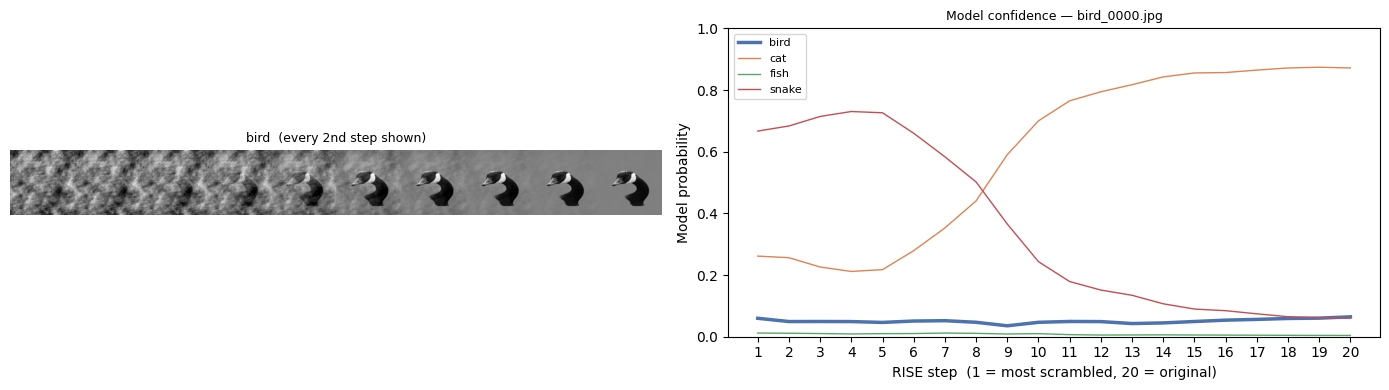

True class: bird  |  Threshold: step None  |  Final prediction: cat


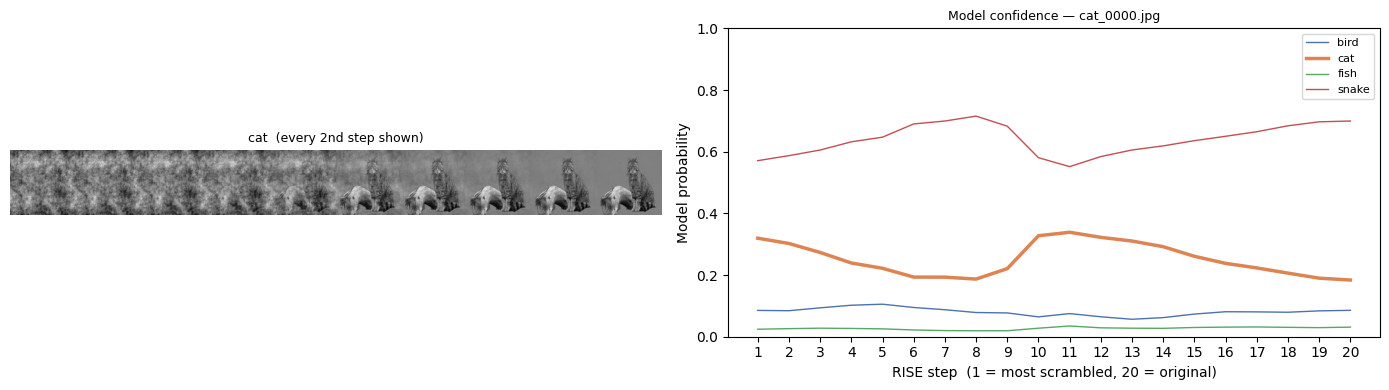

True class: cat  |  Threshold: step None  |  Final prediction: snake


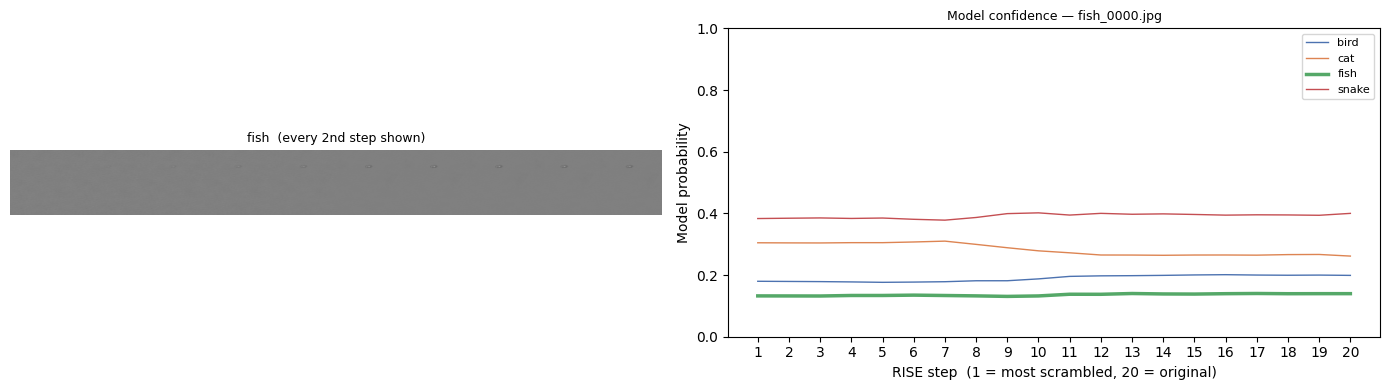

True class: fish  |  Threshold: step None  |  Final prediction: snake


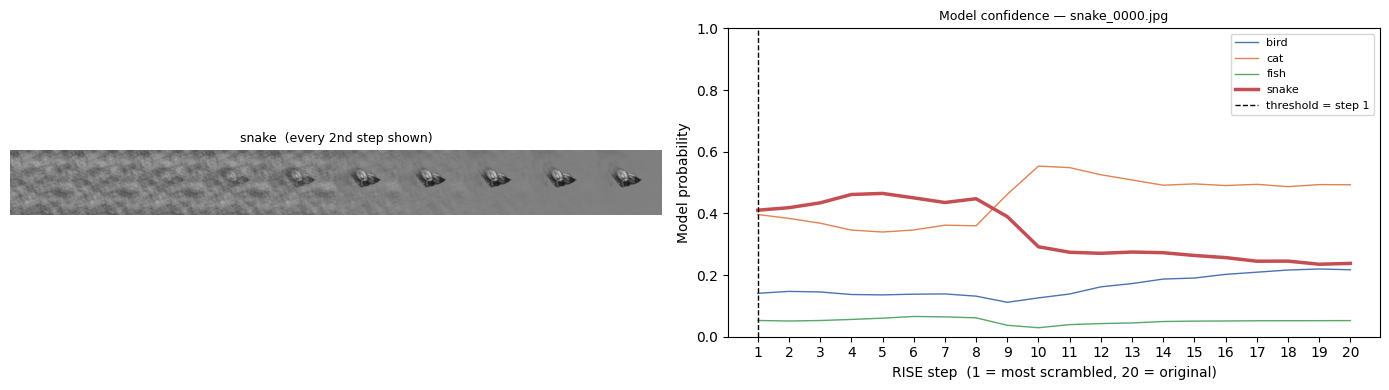

True class: snake  |  Threshold: step 1  |  Final prediction: cat


In [5]:
# Build an untrained model with the same architecture
dls_dummy = dblock_gray.dataloaders(DATA_PATH, batch_size=32)
learn_random = vision_learner(dls_dummy, resnet18, metrics=[accuracy], pretrained=False, n_in=1)
# No learn.load() — weights stay random

print('Random model ready (no weights loaded)')

for cls in CLASSES:
    imgs = sorted((VALID_DIR / cls).glob('*.jpg'))
    plot_rise_inference(imgs[0], learn_random, true_class=cls)

## 4b — Run the baseline experiment

Same RISE pipeline, same 400 validation images, but through the untrained
model. If detection thresholds come out roughly flat and class-agnostic here,
the gray model's snake/bird/cat separation is something it learned. If this
baseline *also* shows a similar pattern, that pattern is structural (RISE
stimuli or architecture), not learned — and the gray-model result above
would need to be reinterpreted.


In [6]:
from rise import run_experiment

print('Running RISE experiment on RANDOM-WEIGHTS baseline (no training)...')
results_random = run_experiment(learn_random, VALID_DIR, classes=CLASSES, verbose=True)

thresholds_random = {cls: [] for cls in CLASSES}
for r in results_random:
    t = r['threshold'] if r['threshold'] is not None else N_STEPS + 1
    thresholds_random[r['class']].append(t)

np.savez('results/thresholds_random.npz', **{cls: np.array(v) for cls, v in thresholds_random.items()})
print('Saved → results/thresholds_random.npz')

for cls in CLASSES:
    vals = thresholds_random[cls]
    detected = sum(1 for v in vals if v <= N_STEPS)
    print(f'  {cls:6s}  mean threshold: {np.mean(vals):.2f}  |  detected: {detected}/{len(vals)}')


Running RISE experiment on RANDOM-WEIGHTS baseline (no training)...

bird: 100 images
  10/100  (3s elapsed)
  20/100  (6s elapsed)
  30/100  (9s elapsed)
  40/100  (13s elapsed)
  50/100  (16s elapsed)
  60/100  (19s elapsed)
  70/100  (22s elapsed)
  80/100  (25s elapsed)
  90/100  (28s elapsed)
  100/100  (31s elapsed)

cat: 100 images
  10/100  (34s elapsed)
  20/100  (37s elapsed)
  30/100  (41s elapsed)
  40/100  (44s elapsed)
  50/100  (47s elapsed)
  60/100  (50s elapsed)
  70/100  (53s elapsed)
  80/100  (57s elapsed)
  90/100  (60s elapsed)
  100/100  (63s elapsed)

fish: 100 images
  10/100  (66s elapsed)
  20/100  (69s elapsed)
  30/100  (72s elapsed)
  40/100  (76s elapsed)
  50/100  (79s elapsed)
  60/100  (82s elapsed)
  70/100  (85s elapsed)
  80/100  (88s elapsed)
  90/100  (91s elapsed)
  100/100  (95s elapsed)

snake: 100 images
  10/100  (98s elapsed)
  20/100  (101s elapsed)
  30/100  (104s elapsed)
  40/100  (107s elapsed)
  50/100  (111s elapsed)
  60/100  (114s 

## 5 — Full experiment: detection thresholds across the validation set

Run the gray model over all 400 validation images (100 per class).
Takes ~10–20 min depending on hardware. Results saved to `results/thresholds_gray.npz`.

**Skip to the plotting cell below if you've already run this.**

In [7]:
from rise import run_experiment
import os

os.makedirs('results', exist_ok=True)

print('Running RISE experiment on gray model...')
results_gray = run_experiment(learn_gray, VALID_DIR, classes=CLASSES, verbose=True)

# Extract detection thresholds (None → step 21 = never detected, treated as max+1)
thresholds = {cls: [] for cls in CLASSES}
for r in results_gray:
    t = r['threshold'] if r['threshold'] is not None else N_STEPS + 1
    thresholds[r['class']].append(t)

# Save
np.savez('results/thresholds_gray.npz', **{cls: np.array(v) for cls, v in thresholds.items()})
print('Saved → results/thresholds_gray.npz')

for cls in CLASSES:
    vals = thresholds[cls]
    detected = sum(1 for v in vals if v <= N_STEPS)
    print(f'  {cls:6s}  mean threshold: {np.mean(vals):.2f}  |  detected: {detected}/{len(vals)}')

Running RISE experiment on gray model...

bird: 100 images
  10/100  (3s elapsed)
  20/100  (6s elapsed)
  30/100  (10s elapsed)
  40/100  (13s elapsed)
  50/100  (16s elapsed)
  60/100  (19s elapsed)
  70/100  (22s elapsed)
  80/100  (26s elapsed)
  90/100  (29s elapsed)
  100/100  (32s elapsed)

cat: 100 images
  10/100  (35s elapsed)
  20/100  (39s elapsed)
  30/100  (42s elapsed)
  40/100  (45s elapsed)
  50/100  (48s elapsed)
  60/100  (52s elapsed)
  70/100  (55s elapsed)
  80/100  (58s elapsed)
  90/100  (61s elapsed)
  100/100  (65s elapsed)

fish: 100 images
  10/100  (68s elapsed)
  20/100  (71s elapsed)
  30/100  (74s elapsed)
  40/100  (78s elapsed)
  50/100  (81s elapsed)
  60/100  (84s elapsed)
  70/100  (88s elapsed)
  80/100  (91s elapsed)
  90/100  (94s elapsed)
  100/100  (97s elapsed)

snake: 100 images
  10/100  (101s elapsed)
  20/100  (104s elapsed)
  30/100  (107s elapsed)
  40/100  (110s elapsed)
  50/100  (114s elapsed)
  60/100  (117s elapsed)
  70/100  (120s 

## 6 — Plot detection threshold distributions

Box plots and mean curves per class, modelled on Kawai Figure 2.

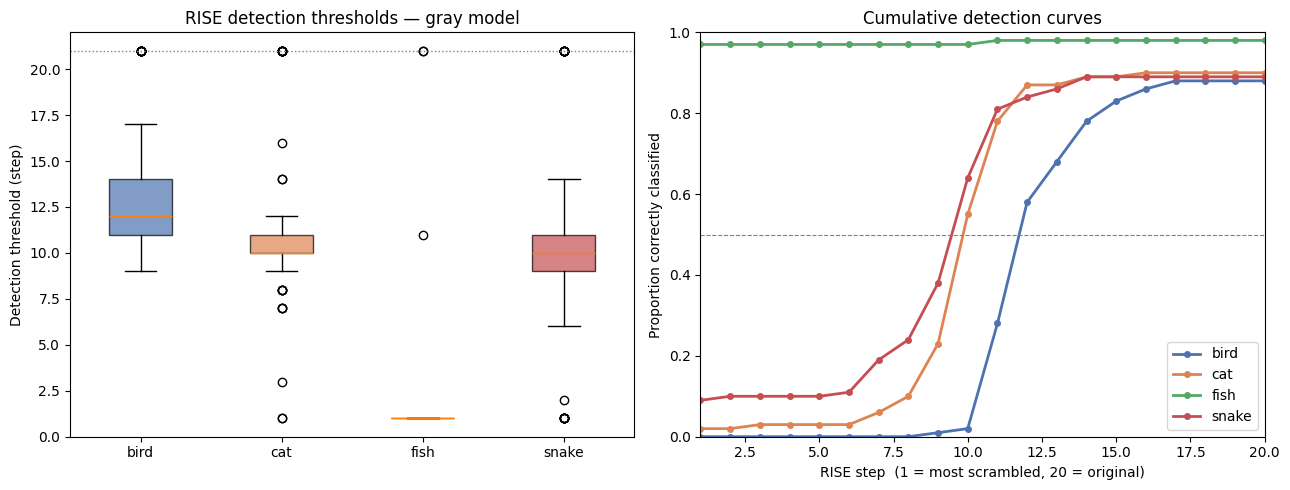

Saved → results/detection_curves_gray.png


In [8]:
# Load saved results (run cell 5 first, or load previously saved data)
data = np.load('results/thresholds_gray.npz')
thresholds = {cls: data[cls] for cls in CLASSES}

colors = {'bird': '#4C72B0', 'cat': '#DD8452', 'fish': '#55A868', 'snake': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plots
ax = axes[0]
box_data = [thresholds[cls] for cls in CLASSES]
bp = ax.boxplot(box_data, labels=CLASSES, patch_artist=True, notch=False)
for patch, cls in zip(bp['boxes'], CLASSES):
    patch.set_facecolor(colors[cls])
    patch.set_alpha(0.7)
ax.axhline(N_STEPS + 1, color='gray', linestyle=':', linewidth=1, label='never detected')
ax.set_ylabel('Detection threshold (step)')
ax.set_title('RISE detection thresholds — gray model')
ax.set_ylim(0, N_STEPS + 2)

# Right: proportion correct at each step (cumulative detection curve)
ax = axes[1]
steps = np.arange(1, N_STEPS + 2)
for cls in CLASSES:
    t = thresholds[cls]
    prop = [(t <= s).mean() for s in steps]
    ax.plot(steps[:-1], prop[:-1], label=cls, color=colors[cls], linewidth=2, marker='o', markersize=4)
ax.set_xlabel('RISE step  (1 = most scrambled, 20 = original)')
ax.set_ylabel('Proportion correctly classified')
ax.set_title('Cumulative detection curves')
ax.set_xlim(1, N_STEPS)
ax.set_ylim(0, 1)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')

plt.tight_layout()
plt.savefig('results/detection_curves_gray.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/detection_curves_gray.png')